# Image to LaTeX -- Full Pipeline
Run each cell in order. Make sure GPU is enabled:
**Runtime > Change runtime type > T4 GPU**

## 1. Mount Google Drive & Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision matplotlib nltk Pillow distance -q

## 2. Load Project (fast restore after runtime reset)
**First time only:** run cell 2a to create `Data_Im2Latx.tar.gz` on Drive.
Then always run cell 2b — copies one archive + extracts locally.

In [2]:
# === 2. RUN AFTER EVERY RUNTIME RESET ===

!mkdir -p /content/CV_220704007

# Copy .py files (tiny, instant)
!cp /content/drive/MyDrive/CV_220704007/*.py /content/CV_220704007/

# Copy zip + extract to local SSD (fast — one big file, -o = overwrite without asking)
!cp /content/drive/MyDrive/CV_220704007/Data_Im2Latx.zip /content/
!unzip -qo /content/Data_Im2Latx.zip -d /content/CV_220704007/
!rm /content/Data_Im2Latx.zip

# Restore checkpoints from Drive if they exist (resume training)
import os, shutil
drive_ckpt = '/content/drive/MyDrive/CV_220704007/checkpoints'
local_ckpt = '/content/CV_220704007/checkpoints'
if os.path.exists(drive_ckpt):
    os.makedirs(local_ckpt, exist_ok=True)
    for f in os.listdir(drive_ckpt):
        shutil.copy2(os.path.join(drive_ckpt, f), local_ckpt)
    print('Restored checkpoints from Drive!')
    !ls -la {local_ckpt}
else:
    print('No checkpoints found on Drive at:', drive_ckpt)

# Also copy vocab.pkl if it exists (avoids rebuilding)
drive_vocab = '/content/drive/MyDrive/CV_220704007/vocab.pkl'
if os.path.exists(drive_vocab):
    shutil.copy2(drive_vocab, '/content/CV_220704007/')
    print('Restored vocab.pkl from Drive!')

%cd /content/CV_220704007
!ls

## 3. Check GPU

In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

## 4. Check Dataset

In [4]:
import os
data_dir = "Data_Im2Latx"
print("Dataset contents:")
for item in os.listdir(data_dir):
    full = os.path.join(data_dir, item)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print("  {}/  ({} files)".format(item, n))
    else:
        sz = os.path.getsize(full)
        print("  {}  ({:.1f} KB)".format(item, sz/1024))

## 5. Build Vocabulary

In [5]:
!python vocab.py

## 6. Train (with attention)
This takes ~1-2 hours on a T4 GPU.

In [ ]:
!python train.py

# Auto-save checkpoints to Drive after training
import shutil, os
save_dir = '/content/drive/MyDrive/CV_220704007/checkpoints'
os.makedirs(save_dir, exist_ok=True)
if os.path.exists('checkpoints'):
    shutil.copytree('checkpoints', save_dir, dirs_exist_ok=True)
    print('Checkpoints saved to Drive!')

## 7. View Training Plots

--- Loss ---


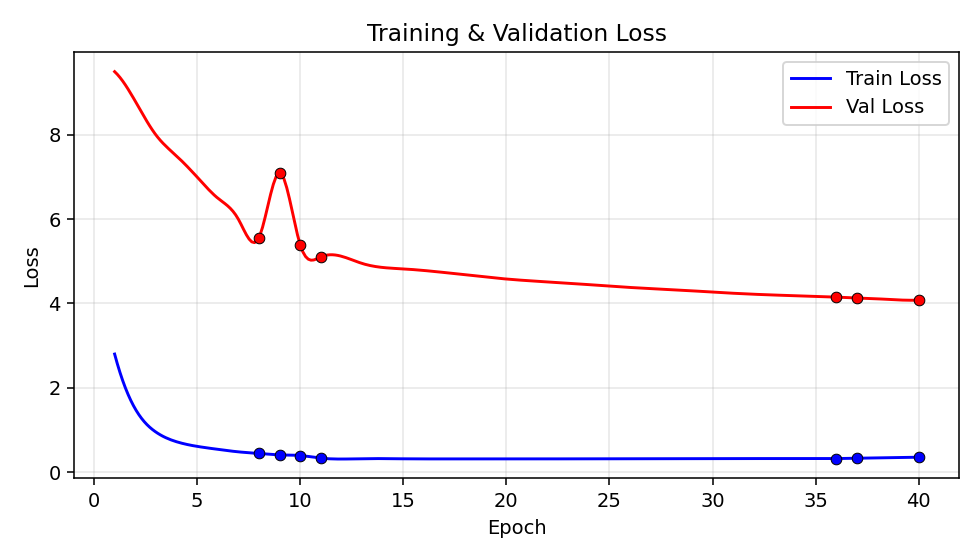

--- BLEU ---


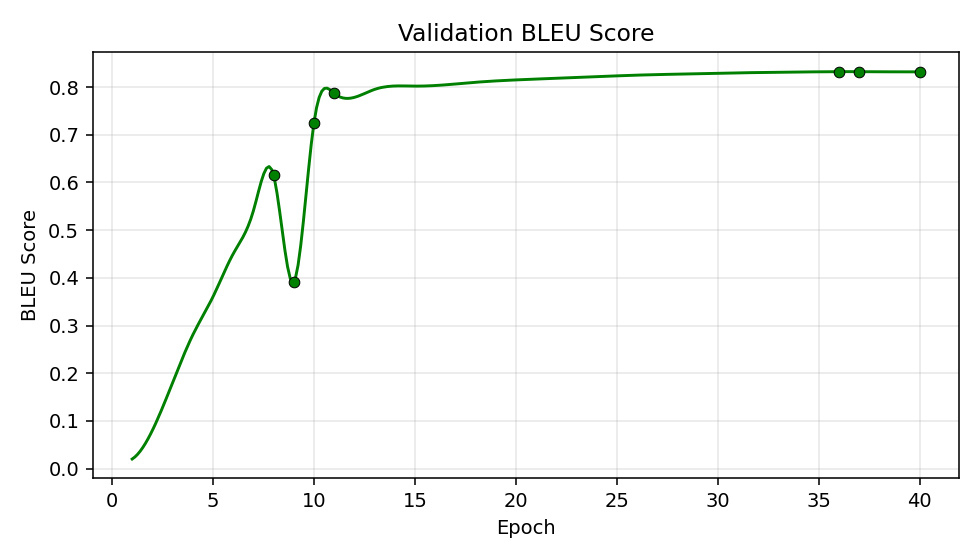

--- Edit Distance ---


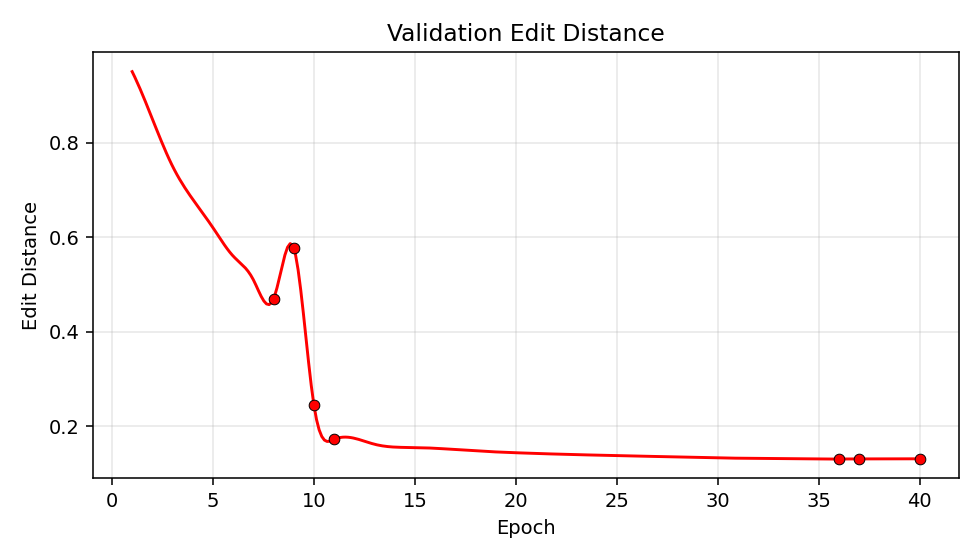

In [1]:
from IPython.display import Image, display
print("--- Loss ---")
display(Image("plots/loss.png"))
print("--- BLEU ---")
display(Image("plots/bleu.png"))
print("--- Edit Distance ---")
display(Image("plots/edit_distance.png"))

## 8. Generate Test Predictions (beam search + post-processing)

In [ ]:
!python predict.py --beam --postprocess

## 9. Preview Predictions

In [1]:
with open("test_formulas.txt", "r") as f:
    lines = f.readlines()
print("Total predictions:", len(lines))
print("\nFirst 10:")
for i, line in enumerate(lines[:10]):
    print("  [{}] {}".format(i, line.strip()))

Total predictions: 10355

First 10:
  [0] \alpha _ { 1 } ^ { r } \gamma _ { 1 } + \ldots + \alpha _ { N } ^ { r } \gamma _ { N } = 0 \quad ( r = 1 , . . , R ) \ ,
  [1] \eta = - \frac { 1 } { 2 } \operatorname { l n } \left( \frac { \operatorname { c o s h } \left( \sqrt { 2 b _ { 0 } } \sqrt { 1 + \alpha ^ { 2 } } y - \operatorname { a r c s i n h } \alpha \right) } { \sqrt { 1 + \alpha ^ { 2 } }})
  [2] P _ { ( 2 ) } ^ { - } = \int \beta d \beta d ^ { 2 } p d ^ { 4 } \lambda \Phi ( - p , - \lambda ) \left( - \frac { p ^ { \prime } p ^ { \prime } } { 2 \beta } \right) \Phi ( p , \lambda ) \, .
  [3] \Gamma ( z + 1 ) = \int _ { 0 } ^ { \infty } \ d x \ e ^ { - x } x ^ { z } .
  [4] \frac { d } { d s } { \bf C } _ { i } = \frac { 1 } { 2 } \epsilon _ { i j k } { \bf C } _ { j } \times { \bf C } _ { k } \, .
  [5] Z = \sum _ { s p i n s s c e s s } W ( a | e , f g | b , c , d | h ) ,
  [6] \left\{ Q ^ { i } , Q ^ { j } \right\} = c ^ { i j } \Gamma ^ { M } C P _ { M } + C c ^ { i j } Z ,

## 10. Evaluate Test Predictions (BLEU + Edit Distance)
Checks if test ground truth exists, then runs both metrics.

In [2]:
import os

test_gt = "Data_Im2Latx/test_formulas.txt"
predicted = "test_formulas.txt"

if os.path.exists(test_gt):
    print("=== Test Set BLEU (4-gram) ===")
    !python bleu_score.py --target-formulas {test_gt} --predicted-formulas {predicted} --ngram 4

    print("\n=== Test Set Edit Distance ===")
    !python edit_distance.py --target-formulas {test_gt} --predicted-formulas {predicted}
else:
    print("No test ground truth found at:", test_gt)
    print("Skipping test evaluation. Will evaluate on validation set instead.")
    print("\n=== Validation Set BLEU (4-gram) ===")
    !python bleu_score.py --target-formulas Data_Im2Latx/validation_formulas.txt --predicted-formulas val_predictions.txt --ngram 4
    print("\n=== Validation Set Edit Distance ===")
    !python edit_distance.py --target-formulas Data_Im2Latx/validation_formulas.txt --predicted-formulas val_predictions.txt

No test ground truth found at: Data_Im2Latx/test_formulas.txt
Skipping test evaluation. Will evaluate on validation set instead.

=== Validation Set BLEU (4-gram) ===
Traceback (most recent call last):
  File "/home/hasan/Desktop/CV_220704007/bleu_score.py", line 68, in <module>
    main(sys.argv[1:])
  File "/home/hasan/Desktop/CV_220704007/bleu_score.py", line 39, in main
    predicted_formulas = open(predicted_formulas_file).readlines()
FileNotFoundError: [Errno 2] No such file or directory: 'val_predictions.txt'

=== Validation Set Edit Distance ===
Traceback (most recent call last):
  File "/home/hasan/Desktop/CV_220704007/edit_distance.py", line 59, in <module>
    main(sys.argv[1:])
  File "/home/hasan/Desktop/CV_220704007/edit_distance.py", line 31, in main
    predicted_formulas = open(predicted_formulas_file).readlines()
FileNotFoundError: [Errno 2] No such file or directory: 'val_predictions.txt'


## 11. Evaluate on Validation Set
Uses the provided evaluation scripts.

In [6]:
# first generate val predictions
# (we reuse predict.py but point it at val images -- quick hack)
import config as C
import torch
from torch.utils.data import DataLoader
from vocab import Vocab
from dataset import FormulaDataset, collate_train
from model import Im2Latex

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab = Vocab.load()
ckpt = torch.load("checkpoints/model_best.pt", map_location=dev)
model = Im2Latex(ckpt["vocab_size"]).to(dev)
model.load_state_dict(ckpt["model"])
model.eval()

val_ds = FormulaDataset(C.VAL_IMAGES_DIR, C.VAL_FORMULAS, vocab, training=False)
val_ld = DataLoader(val_ds, C.BATCH, shuffle=False, collate_fn=collate_train)

val_preds = []
for imgs, tgts, lens in val_ld:
    imgs = imgs.to(dev)
    seqs = model.greedy(imgs, vocab.sos_id, vocab.eos_id)
    for seq in seqs:
        val_preds.append(" ".join(vocab.decode(seq)))

with open("val_predictions.txt", "w") as f:
    for p in val_preds:
        f.write(p + "\n")
print("Wrote {} val predictions".format(len(val_preds)))

Loaded vocab (544 tokens) <- /home/hasan/Desktop/CV_220704007/vocab.pkl
[FormulaDataset] 8370 samples from /home/hasan/Desktop/CV_220704007/Data_Im2Latx/images_val


KeyboardInterrupt: 

In [4]:
print("=== BLEU ===")
!python bleu_score.py --target-formulas Data_Im2Latx/validation_formulas.txt --predicted-formulas val_predictions.txt --ngram 4

print("\n=== Edit Distance ===")
!python edit_distance.py --target-formulas Data_Im2Latx/validation_formulas.txt --predicted-formulas val_predictions.txt

=== BLEU ===
Traceback (most recent call last):
  File "/home/hasan/Desktop/CV_220704007/bleu_score.py", line 68, in <module>
    main(sys.argv[1:])
  File "/home/hasan/Desktop/CV_220704007/bleu_score.py", line 39, in main
    predicted_formulas = open(predicted_formulas_file).readlines()
FileNotFoundError: [Errno 2] No such file or directory: 'val_predictions.txt'

=== Edit Distance ===
Traceback (most recent call last):
  File "/home/hasan/Desktop/CV_220704007/edit_distance.py", line 59, in <module>
    main(sys.argv[1:])
  File "/home/hasan/Desktop/CV_220704007/edit_distance.py", line 31, in main
    predicted_formulas = open(predicted_formulas_file).readlines()
FileNotFoundError: [Errno 2] No such file or directory: 'val_predictions.txt'


## 12. Visual Comparison: Image vs Prediction vs Ground Truth
Shows 8 random validation samples side by side. Each row: the input image, the ground truth LaTeX, and the model's prediction.

In [5]:
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image as PILImage
import config as C
from vocab import read_formulas

# Load ground truth and predictions
gt_formulas = read_formulas(C.VAL_FORMULAS)
with open("val_predictions.txt", "r") as f:
    pred_formulas = [line.strip().split() for line in f.readlines()]

# Pick 8 random samples
num_samples = 8
indices = random.sample(range(len(gt_formulas)), num_samples)

fig = plt.figure(figsize=(16, num_samples * 2.5))
gs = gridspec.GridSpec(num_samples, 2, width_ratios=[1, 2], hspace=0.4, wspace=0.3)

for row, idx in enumerate(indices):
    # Load image
    img_path = os.path.join(C.VAL_IMAGES_DIR, "{:05d}.png".format(idx))
    img = PILImage.open(img_path).convert("L")

    gt_str = " ".join(gt_formulas[idx])
    pred_str = " ".join(pred_formulas[idx]) if idx < len(pred_formulas) else "N/A"

    # Check if prediction matches ground truth
    match = (gt_str == pred_str)
    color = "#e8f5e9" if match else "#fff3e0"  # green bg if match, orange if not

    # Left: image
    ax_img = fig.add_subplot(gs[row, 0])
    ax_img.imshow(img, cmap="gray")
    ax_img.set_title("Sample #{}".format(idx), fontsize=9, fontweight="bold")
    ax_img.axis("off")

    # Right: GT vs Prediction text
    ax_txt = fig.add_subplot(gs[row, 1])
    ax_txt.axis("off")
    ax_txt.set_xlim(0, 1)
    ax_txt.set_ylim(0, 1)

    # Truncate long formulas for display
    gt_show = gt_str[:120] + ("..." if len(gt_str) > 120 else "")
    pred_show = pred_str[:120] + ("..." if len(pred_str) > 120 else "")

    ax_txt.text(0.02, 0.72, "GT:   " + gt_show,
                fontsize=7, fontfamily="monospace", color="black",
                verticalalignment="top", wrap=True)
    ax_txt.text(0.02, 0.32, "Pred: " + pred_show,
                fontsize=7, fontfamily="monospace",
                color="green" if match else "#d84315",
                verticalalignment="top", wrap=True)

    status = "MATCH" if match else "DIFF"
    ax_txt.text(0.98, 0.5, status, fontsize=8, fontweight="bold",
                color="green" if match else "red",
                ha="right", va="center")

    ax_txt.set_facecolor(color)

plt.suptitle("Validation Samples: Ground Truth vs Prediction", fontsize=13, fontweight="bold")
plt.savefig("plots/comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved comparison plot to plots/comparison.png")

FileNotFoundError: [Errno 2] No such file or directory: 'val_predictions.txt'

## 13. Save Results to Google Drive

In [ ]:
import shutil, os

save_dir = "/content/drive/MyDrive/CV_220704007"
os.makedirs(save_dir, exist_ok=True)

shutil.copy("test_formulas.txt", save_dir)
shutil.copytree("plots", os.path.join(save_dir, "plots"), dirs_exist_ok=True)
shutil.copytree("checkpoints", os.path.join(save_dir, "checkpoints"), dirs_exist_ok=True)

print("Saved everything to", save_dir)
print("Contents:")
for root, dirs, files in os.walk(save_dir):
    for f in files:
        print("  ", os.path.join(root, f))

## 14. Download Results Directly

In [ ]:
from google.colab import files
files.download("test_formulas.txt")
files.download("plots/loss.png")
files.download("plots/bleu.png")
files.download("plots/edit_distance.png")
files.download("plots/comparison.png")

---
**Done!** Copy the BLEU and Edit Distance numbers from cell 10 into `report.md`.